# Batch filter and render "Codeless" Jupyter Notebook

This notebook allows you to filter and render a super-resolution image from localizations generated by Picasso localization software and then assess quality control metrics such as Decorrelation analysis.

To use this notebook you don't need to interact with any code, just run cells in order and a graphical user interface will pop-up showcasing the parameters for each step. Output will be saved on the same directory as the loaded image.

The only requirements for this code is to have python >= 3.9 and to install the libraries Nanopyx (https://github.com/HenriquesLab/NanoPyx) and Picasso (https://github.com/jungmannlab/picasso). 

To install run the notebook, please create an environment with the proper libraries as in the following example:

1. Open the console/terminal and create a new conda environment: `conda create --name picasso python=3.10`.
2. Activate the environment: `conda activate picasso`.
3. Install Nanopyx and Picasso packages using: `pip install nanopyx[jupyter]` and `pip install picassosr`.
4. Run the cells in the notebook using the environment.

**Nanopyx**: Bruno M. Saraiva, Inês M. Cunha, António D. Brito, Gautier Follain, Raquel Portela, Robert Haase, Pedro M. Pereira, Guillaume Jacquemet, Ricardo Henriques bioRxiv 2023.08.13.553080; doi: https://doi.org/10.1101/2023.08.13.553080 

**Picasso**: Schnitzbauer, J., Strauss, M., Schlichthaerle, T. et al. Super-resolution microscopy with DNA-PAINT. Nat Protoc 12, 1198–1228 (2017). https://doi.org/10.1038/nprot.2017.024

**DecorrAnalysis**: Descloux A, Grußmayer KS, Radenovic A. Parameter-free image resolution estimation based on decorrelation analysis. Nat Methods. 2019 Sep;16(9):918-924. https://10.1038/s41592-019-0515-7 

## Step 1: load the necesary packages

In [1]:
#!pip install -q "nanopyx[all]" == 0.6.0 
#!pip install -q picassosr == 0.7.0

import io
import os

%matplotlib inline
%matplotlib widget

from matplotlib import colormaps
from matplotlib import pyplot as plt
from pylab import *

from IPython.display import display, clear_output
import ipywidgets as widgets
from PIL import Image

from picasso import io as picasso_io

from nanopyx.core.analysis.decorr import DecorrAnalysis
from nanopyx.core.utils.easy_gui import EasyGui
from nanopyx.core.utils.find_files import find_files

from function_scripts import plotting
from function_scripts import processing

/Users/avesga/miniforge3/envs/nanopicasso/lib/python3.10/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


Cupy implementation is not available. Make sure you have the right version of Cupy and CUDA installed.
Optional dependecy Dask_image is not installed. Implementations using it will be ignored.


## Step 2: load your data

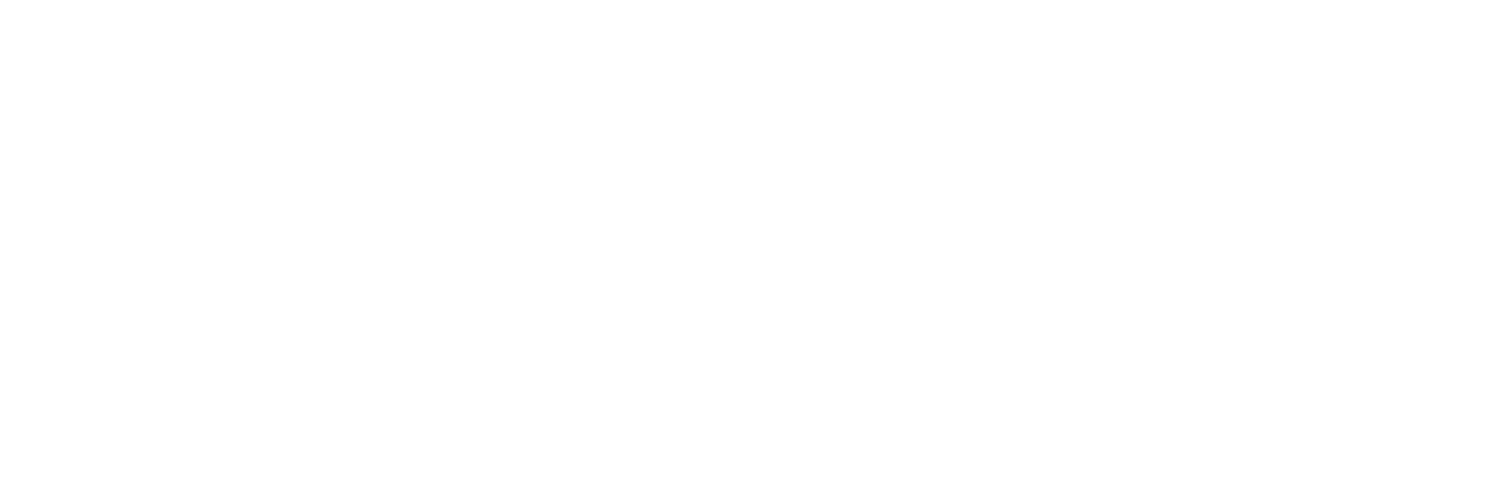

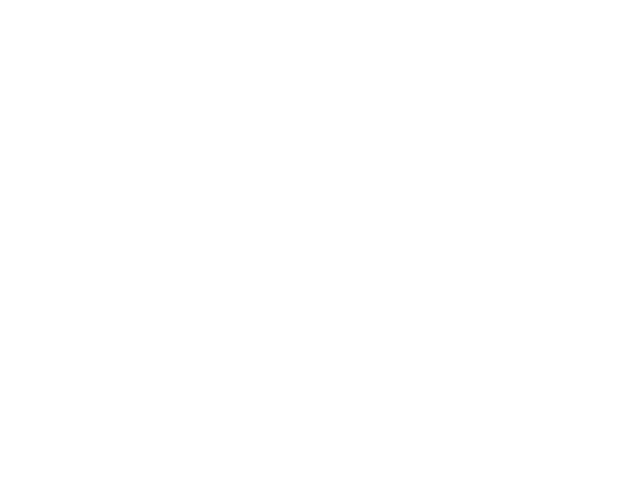

In [ ]:
#@title Load image stack
# Create a GUI
gui_data = EasyGui("Data Loader")
global own_data

own_data = True

def on_button_load_data_clicked(b):
    clear_output()
    gui_data.show()

    # extract the path without the filename from gui_filter_render["upload"].selected
    global path
    global file_save
    path = os.path.dirname(gui_data["upload"].selected)
    file_save = os.path.basename(gui_data["upload"].selected)

    own_data = True
    # disable button
    gui_data["load_data_own"].disabled = True
    gui_data["load_data_own"].description = "Loading..."

    global dataset_original
    dataset_original, _ = picasso_io.load_locs(gui_data["upload"].selected)
    
    gui_data["load_data_own"].disabled = False
    gui_data["load_data_own"].description = "Load data"
    image_hist = plotting.plot_histograms(dataset_original)
    image_render = processing.render_data(dataset_original, gui_data)

    gui_data._main_display.children = gui_data._main_display.children + (image_hist, image_render, )
    plt.clf()


clear_output()
gui_data.add_label("Select data to use:")
gui_data.add_file_upload("upload", accept="*hdf5")
gui_data.add_dropdown("cmaps", description="Colormap:",
                    options=sorted(list(colormaps)),
                    value="turbo", remember_value=False)
gui_data.add_button("load_data_own", description="Load data")
gui_data["load_data_own"].on_click(on_button_load_data_clicked)

gui_data.show()

## Step 3: filter and render the data

## Filter localizations 

The loaded localizations can be filtered according to photon number and sigma of the fitted gaussian of every localization. First, select the high and low bounds for both photons and sigma. Then select the oversampling desired for the rendering.

A central ROI to filter and render can be set unticking the checkbox and selectig the lateral size of the ROI in the original image.

## Filter parameters

### Estimating the parameters

This optional functionality helps you estimate filtering parameters that work for most samples. It uses logical inputs, like the expected size of the point spread function (PSF), photon dispersion, and background levels. Ensure these initial parameters—based on your optical setup and sample properties—are accurate before proceeding to estimate other filtering thresholds.

- **Emission wavelength**: The wavelength of light emitted by the fluorophore (nm).
- **NA of the objective**: The numerical aperture of the microscope objective.
- **Pixel size**: The size of a single pixel in the imaging system (nm).

### Localization features filters

Each localization is associated with a photon count, fitting uncertainty, and background. Use these parameters to filter individual features and refine the dataset for accurate analysis.

#### Photons bounds
- **Lower photons bound**: The minimum number of photons required for a localization to be considered valid.
- **Upper photons bound**: The maximum number of photons allowed for a localization to be included.

#### Fitting Uncertainty Bounds (Sigma)
- **Lower sigma bound**: The minimum uncertainty (sigma) in the fit that a localization can have to be included.
- **Upper sigma bound**: The maximum uncertainty (sigma) allowed.

#### Background bounds
- **Lower background bound**: The minimum acceptable background signal for inclusion.
- **Upper background bound**: The maximum acceptable background signal.

#### Density filter
- **Min number of neighbours**: The minimum number of localizations required in the specified radius for inclusion.
- **Density filter radius (um)**: The radius around a localization within which neighbors are counted, specified in micrometers.

#### Frame range and magnification used for rendering
- **Magnification**: A scaling factor applied to adjust for the magnification of the optical setup.
- **First frame**: The first frame to consider for analysis or filtering.
- **Last frame**: The last frame to consider.

### [Optional] Filtering serial data

Once the parameters are satisfactory, a whole folder can be analyzed by pressing **Filter and render a folder** button. Then all the *.hdf5 files within the folder will be filtered and rendered with the selected parameters. Please note that there has to be always a pair of *.hdf5 and *.yaml files with the same name.

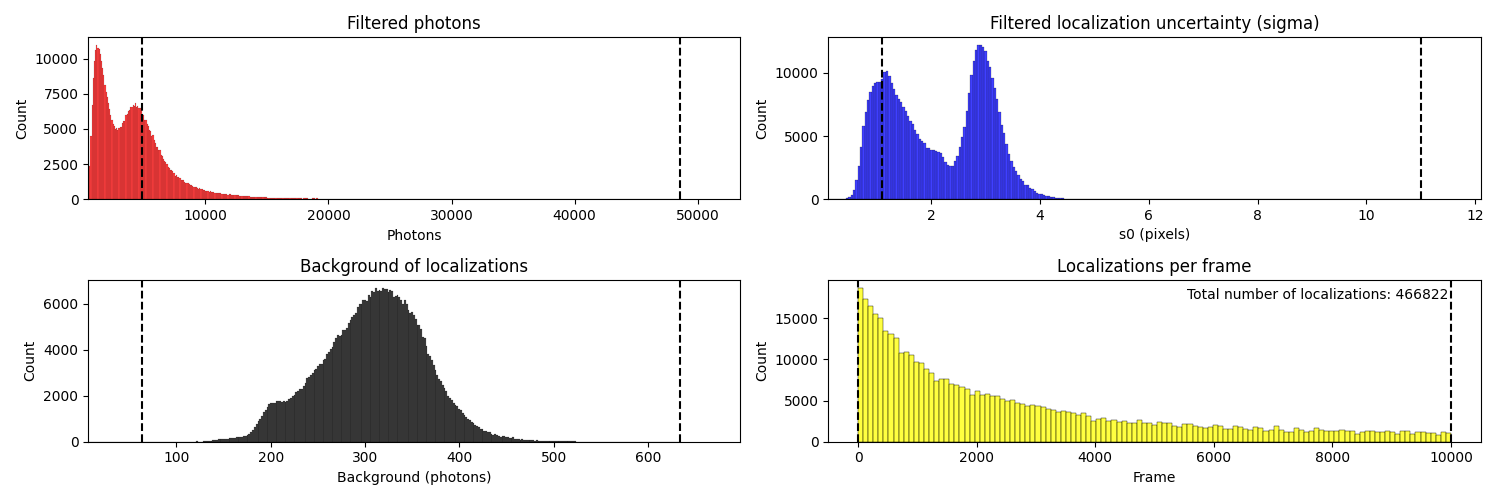

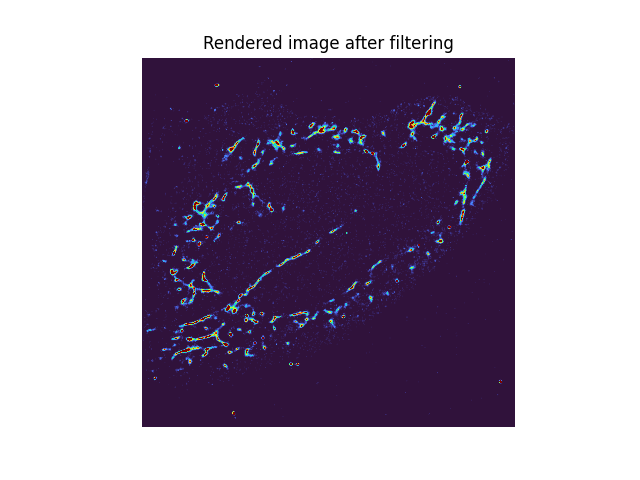

In [3]:
gui_filter_render = EasyGui("Select Filters")

def estimate_parameters(b):

    max_photons_hist, max_sigma_hist, _, max_frame_hist = processing.define_max_hist(dataset_original)
    min_bkg, max_bkg = processing.find_optimal_bkg(dataset_original)
    min_photons = processing.find_optimal_photons(dataset_original)

    # Asign values to the sliders
    gui_filter_render["sigma_high"].value = max_sigma_hist
    gui_filter_render["photons_low"].value = min_photons
    gui_filter_render["photons_high"].value = max_photons_hist
    gui_filter_render["bkg_low"].value = min_bkg
    gui_filter_render["bkg_high"].value = max_bkg
    gui_filter_render["frames_low"].value = 0.01*max_frame_hist
    gui_filter_render["frames_high"].value = max_frame_hist

    wavelength = float(gui_filter_render["wavelength"].value)
    NA_obj = float(gui_filter_render["NA"].value)
    pixel_size = float(gui_filter_render["pixel_size"].value)

    # Estimate sigma
    sigma_expected = processing.estimate_sigma(wavelength, NA_obj, pixel_size)
    gui_filter_render["sigma_low"].value = sigma_expected*0.8 # take sigma values slightly bellow the FWHM expected

    gui_filter_render.show()
    gui_filter_render._main_display.children = gui_filter_render._main_display.children

def analyze_dataset_folder(b):

    path = os.path.dirname(gui_filter_render["upload"].selected)
    # Create a folder in path called "analysis"
    path_save = os.path.join(path, "analysis")
    if not os.path.exists(path_save):
        os.makedirs(path_save)
    
    # Run over the *.hdf5 files in path
    files = find_files(path, "hdf5")
    print(files)

    pixel_size = float(gui_filter_render["pixel_size"].value)

    plotting.write_params_to_file(gui_filter_render, path_save, "All_files")

    for file in files:

        file_save_folder = os.path.basename(file)
        print("Analyzing ", file_save_folder)

        dataset_folder, info = picasso_io.load_locs(file)
        _ = processing.extract_render_save(path_save, file_save_folder, gui_filter_render, dataset_folder, pixel_size)

    print("Finished analyzing folder")

def analyze_dataset(b):

    gui_filter_render.save_settings()

    # if first_click exists
    if not 'first_click' in globals():
        global first_click
        first_click = True

    global oversampling
    _,_, _, _, _, _, _, _, oversampling, _, _ = processing.read_slidebars_filter(gui_filter_render)
    pixel_size = float(gui_filter_render["pixel_size"].value)

    gui_filter_render["filter_render"].disabled = True
    gui_filter_render["filter_render"].description = "Running..."

    global image_oversampling
    image_oversampling = processing.extract_render_save(path, file_save, gui_filter_render, dataset_original, pixel_size)

    gui_filter_render["filter_render"].disabled = False
    gui_filter_render["filter_render"].description = "Filter and render"

    image_hist = plotting.plot_histograms_filter(dataset_original, gui_filter_render)
    
    fig, axs = plt.subplots()

    axs.imshow(image_oversampling, alpha=1, vmin=0, vmax=image_oversampling.flatten().mean()+image_oversampling.flatten().std(), cmap=gui_data["cmaps"].value, )
    axs.axis("off")
    axs.set_title('Rendered image after filtering')

    plotting.write_params_to_file(gui_filter_render, path, file_save)

    img_buf = io.BytesIO()
    plt.savefig(img_buf, format="jpeg")
    rendered_plot = widgets.Output()
    with rendered_plot:
        display(Image.open(img_buf))

    # If this was sucessfull, enable analyze whole folder save
    if first_click:
        first_click = False

        gui_filter_render.add_label("--------------------")
        gui_filter_render.add_label("If these parameters are satisfactory, you can analyze a full folder.")
        gui_filter_render.add_label("Select the folder to analyze:")

    gui_filter_render["update_histograms"].disabled = False

    gui_filter_render.add_file_upload("upload")
    gui_filter_render.add_button("filter_render_folder", description="[Optional] Filter and render a folder")
    gui_filter_render["filter_render_folder"].on_click(analyze_dataset_folder)
    
    gui_filter_render.show()

    gui_filter_render._main_display.children = gui_filter_render._main_display.children + (image_hist, rendered_plot)


def update_plot(b):

    lower_bound_sigma, upper_bound_sigma, lower_bound_photons, upper_bound_photons, lower_bound_bkg, upper_bound_bkg, min_frame, max_frame, _, _, _ = processing.read_slidebars_filter(gui_filter_render)

    image_hist = plotting.plot_histograms_filter(dataset_original, lower_bound_photons, upper_bound_photons, lower_bound_sigma, upper_bound_sigma, lower_bound_bkg, upper_bound_bkg, min_frame, max_frame)
    gui_filter_render._main_display.children = gui_filter_render._main_display.children + (image_hist, )

    gui_filter_render.show()

gui_filter_render.add_label("Measurement information to estimate sigma filtering:")

gui_filter_render.add_float_slider("wavelength", description="Emission wavelength (nm):", min=400, max=800, value=500)
gui_filter_render.add_float_slider("NA", description="NA of the objective:", min=0, max=1.5, value=1.3)
gui_filter_render.add_float_slider("pixel_size", description="Pixel size (nm):", min=0, max=300, value=140)

gui_filter_render.add_button("estimate_sigma", description="[Optional] Estimate optimal parameters")
gui_filter_render["estimate_sigma"].on_click(estimate_parameters)

gui_filter_render.add_label("--------------------")

gui_filter_render.add_label("Select filters:")

# define limits of histograms
max_photons_hist, max_sigma_hist, max_bkg_hist, max_frame_hist = processing.define_max_hist(dataset_original)

gui_filter_render.add_float_slider("photons_low", description="Lower photons bound:", min=0, max=max_photons_hist, value=max_photons_hist*0.1)
gui_filter_render.add_float_slider("photons_high", description="Upper photons bound:", min=0, max=max_photons_hist, value=max_photons_hist)

gui_filter_render.add_float_slider("sigma_low", description="Lower sigma bound:", min=0, max=max_sigma_hist, value=max_sigma_hist*0.1)
gui_filter_render.add_float_slider("sigma_high", description="Upper sigma bound:", min=0, max=max_sigma_hist, value=max_sigma_hist)

gui_filter_render.add_float_slider("bkg_low", description="Lower background bound:", min=0, max=max_bkg_hist, value=max_bkg_hist*0.1)
gui_filter_render.add_float_slider("bkg_high", description="Upper background bound:", min=0, max=max_bkg_hist, value=1000)

gui_filter_render.add_label("--------------------")

gui_filter_render.add_label("Density filter:")
gui_filter_render.add_dropdown("Density_filter_option", description="Apply density filter: ",
                    options=[True, False],
                    value=False, remember_value=False)
gui_filter_render.add_int_slider("density_num_neighbours", description="Min number of neighbours:", min=0, max=100, value=20)
gui_filter_render.add_float_slider("density_radius", description="Density filter radius (um):", min=0, max=2, value=0.5)

gui_filter_render.add_label("--------------------")


gui_filter_render.add_label("Select magnification in reconstruction:")
gui_filter_render.add_int_slider("magnification", description="Magnification:", min=0, max=15, value=2)

gui_filter_render.add_label("--------------------")

gui_filter_render.add_label("Use a subset of frames to render:")
gui_filter_render.add_float_slider("frames_low", description="First frame:", min=0, max=max_frame_hist, value=0)
gui_filter_render.add_float_slider("frames_high", description="Last frame:", min=0, max=max_frame_hist, value=max_frame_hist)

gui_filter_render.add_label("Select central ROI size to render:")
gui_filter_render.add_int_slider("roi_size", description="ROI size (px):", min=0, max=4000, value=200)
gui_filter_render.add_checkbox("use_full_roi", description="Use full ROI", value=True)

gui_filter_render.add_button("filter_render", description="Filter and render loaded file")
gui_filter_render["filter_render"].on_click(analyze_dataset)

gui_filter_render.add_button("update_histograms", description="[Optional] Update the histograms")
gui_filter_render["update_histograms"].on_click(update_plot)
gui_filter_render["update_histograms"].disabled = True

gui_filter_render.show()

## Step 4: compute the resolution of the rendered image

### Calculate Decorrelation analysis resolution of the SR image
#### Image Decorrelation Analysis Parameters:

- **Pixel Size:** Pixel size of the image. Used to calculte resolution values.
- **Units:** Pixel size units.
- **Radius Min/Max:** Resolution calculation by Decorrelation Analysis is performed in the frequency space. These parameters define the range of radii to be used in the calculation. 


In [4]:
gui_decorr = EasyGui("DecorrAnalysis")

def run_decorr(b):
    clear_output()
    gui_decorr.show()
    gui_decorr.save_settings()
    units = gui_decorr["units"].value
    rmin = gui_decorr["rmin"].value
    rmax = gui_decorr["rmax"].value
    gui_decorr["run"].disabled = True
    gui_decorr["run"].description = "Calculating..."
    global decorr_calculator
    decorr_calculator = DecorrAnalysis(pixel_size=pixel_size/oversampling, units=units, rmin=rmin, rmax=rmax)
    decorr_calculator.run_analysis(image_oversampling)
    gui_decorr["run"].disabled = False
    gui_decorr["run"].description = "Calculate"
    plot = decorr_calculator.plot_results()
    plt.imshow(plot)
    plt.savefig(os.path.join(path, f"{file_save}_decorrelation.png"), dpi=300)
    plt.axis("off")
    img_buf = io.BytesIO()
    plt.savefig(img_buf, format="jpeg")
    output_plot = widgets.Output()
    with output_plot:
        display(Image.open(img_buf))
    gui_decorr._main_display.children = gui_decorr._main_display.children + (widgets.Label(value="Real pixel size of rendered image is: " + str(pixel_size/oversampling) + "nm for magnification " + str(oversampling) + "x"),output_plot,)
    plt.clf()

pixel_size = float(gui_filter_render["pixel_size"].value)

gui_decorr.add_int_slider("pixel_size", description="Experimental Pixel Size:", min=0.01, max=1000, value=pixel_size, remember_value=False)
gui_decorr.add_dropdown("units", description="Units: ", options=["nm", "um", "mm"], value="nm")
gui_decorr.add_float_slider("rmin", description="Radius Min:", min=0.0, max=0.5, value=0.0)
gui_decorr.add_float_slider("rmax", description="Radius Max:", min=0.5, max=1.0, value=1.0)
gui_decorr.add_checkbox("save", description="Save Output", value=True)
gui_decorr.add_button("run", description="Calculate")
gui_decorr["run"].on_click(run_decorr)
gui_decorr.show()